#  Fake News Detection — Capstone Project
### ML, Deep Learning & NLP Applications
---

##  Libraries

In [21]:
import warnings, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ccccee',
    'text.color':       '#ddddff',
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'grid.color':       '#2a2a4a',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})
PALETTE = ['#7b5ea7', '#4ecdc4', '#ff6b6b', '#ffd93d', '#6bcb77']
print("ibraries loaded")

ibraries loaded


---
##  Step 1 — Machine Learning Models

### 1.1 Load & Explore the Data

In [22]:
import pandas as pd
import subprocess

# Check the file type of True.csv
result = subprocess.run(['file', 'data/True.csv'], capture_output=True, text=True)
print(f"File type of data/True.csv: {result.stdout.strip()}")

# Reverting to previous approach as the file is not a valid zip archive.
# The file still presents issues as a CSV, but the zipfile approach was incorrect.
df_true = pd.read_csv('data/True.csv', encoding='latin1', on_bad_lines='skip', engine='python')
df_fake = pd.read_csv('data/Fake.csv', encoding='latin1', on_bad_lines='skip', engine='python')
df_true['label'] = 1   # Real
df_fake['label'] = 0   # Fake
df = pd.concat([df_true, df_fake], ignore_index=True).sample(frac=1, random_state=42)
print(f"Dataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
print(f"Missing values:\n{df.isnull().sum()}")
df.head(3)

File type of data/True.csv: data/True.csv: CSV text
Dataset shape : (25242, 5)
Columns       : ['title', 'text', 'subject', 'date', 'label']
Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


,title,text,subject,date,label
16598,Africa eyes senior Trump envoy visit for U.S. ...,ADDIS ABABA (Reuters) - U.S. Ambassador to the...,worldnews,"October 23, 2017",1
12932,Britain to propose new language on Irish borde...,DUBLIN (Reuters) - British Prime Minister Ther...,worldnews,"December 6, 2017",1
21718,WATCH: War Veteran John McCain DESTROYS Draft...,John McCain is far more qualified to comment o...,News,"September 27, 2017",0


####  Class Balance

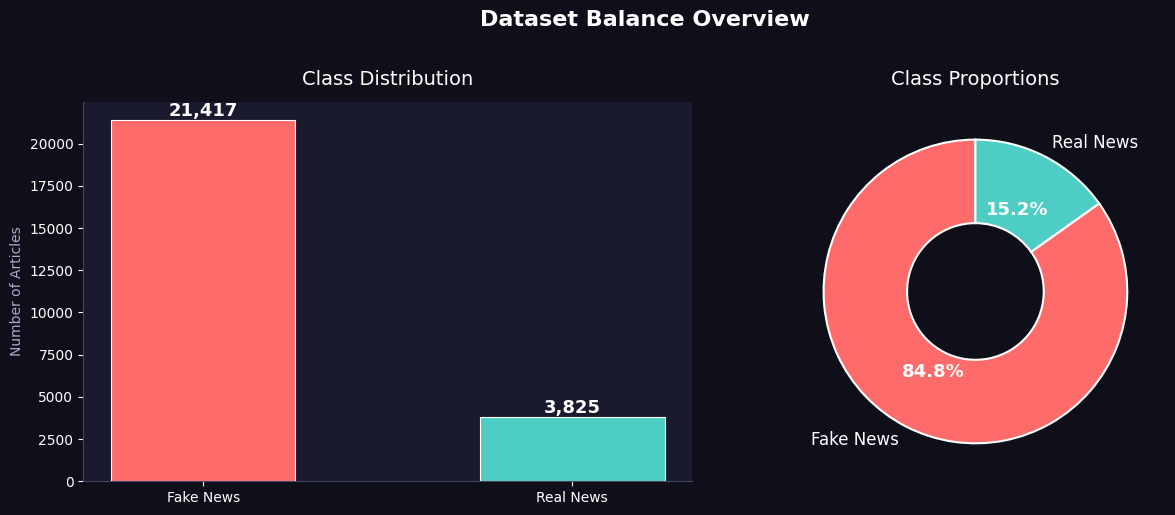

In [23]:
counts = df['label'].value_counts()
labels_txt = ['Fake News', 'Real News']
colors = ['#ff6b6b', '#4ecdc4']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f1a')

# Bar chart
ax = axes[0]
ax.set_facecolor('#1a1a2e')
bars = ax.bar(labels_txt, counts.values, color=colors, width=0.5,
              edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=13, color='white', fontweight='bold')
ax.set_title('Class Distribution', fontsize=14, color='white', pad=12)
ax.set_ylabel('Number of Articles', color='#aaaacc')
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)

# Donut chart
ax2 = axes[1]
ax2.set_facecolor('#0f0f1a')
wedges, texts, autotexts = ax2.pie(
    counts.values, labels=labels_txt, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
    textprops={'color': 'white', 'fontsize': 12})
for at in autotexts:
    at.set_color('white'); at.set_fontweight('bold'); at.set_fontsize(13)
ax2.set_title('Class Proportions', fontsize=14, color='white', pad=12)

plt.suptitle('Dataset Balance Overview', fontsize=16, color='white',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/01_class_balance.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

### 1.2 Prepare the Data

In [24]:
stop_words = set(stopwords.words('english'))

def clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return ' '.join(w for w in text.split() if w not in stop_words)

df['clean_text'] = (df['title'] + ' ' + df['text']).apply(clean)

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Train : {X_train_tfidf.shape}  |  Test : {X_test_tfidf.shape}")

Train : (20193, 5000)  |  Test : (5049, 5000)


### 1.3 Train & Compare ML Models

In [25]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
cms     = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, preds),  4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall'   : round(recall_score(y_test, preds),    4),
        'F1-Score' : round(f1_score(y_test, preds),        4),
    }
    cms[name] = confusion_matrix(y_test, preds)
    print(f"done — F1: {results[name]['F1-Score']:.4f}")

results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
print("\n", results_df)

Training Logistic Regression... done — F1: 0.9970
Training Random Forest... done — F1: 0.9994
Training KNN... done — F1: 0.9636
Training Gradient Boosting... done — F1: 0.9991

                      Accuracy  Precision  Recall  F1-Score
Random Forest          0.9990     0.9988  1.0000    0.9994
Gradient Boosting      0.9984     0.9991  0.9991    0.9991
Logistic Regression    0.9949     0.9942  0.9998    0.9970
KNN                    0.9366     0.9406  0.9876    0.9636


####  Confusion Matrices

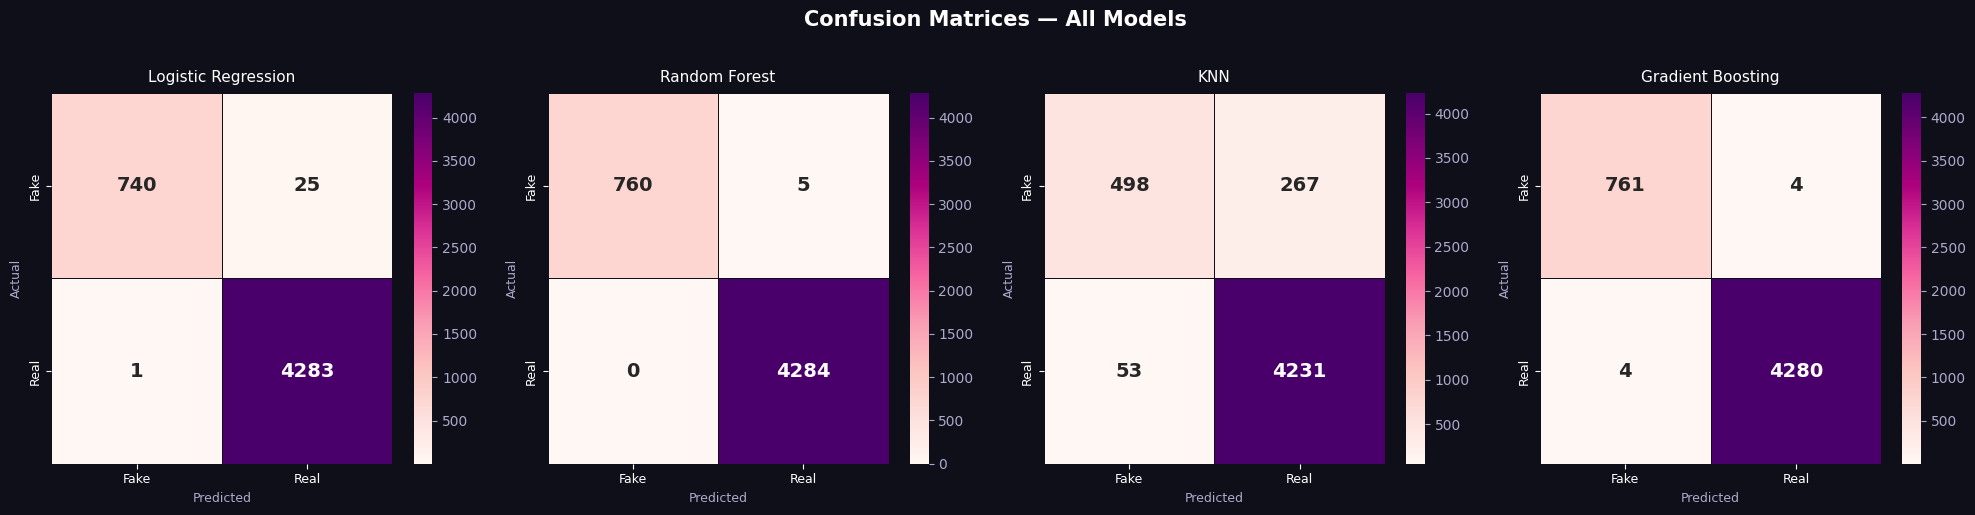

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, (name, cm) in zip(axes, cms.items()):
    ax.set_facecolor('#1a1a2e')
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='RdPu',
                linewidths=0.5, linecolor='#0f0f1a',
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, color='white', fontsize=11, pad=8)
    ax.set_xlabel('Predicted', color='#aaaacc', fontsize=9)
    ax.set_ylabel('Actual', color='#aaaacc', fontsize=9)
    ax.tick_params(colors='white', labelsize=9)

plt.suptitle('Confusion Matrices — All Models', fontsize=15,
             color='white', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/02_confusion_matrices.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

####  Metrics Comparison

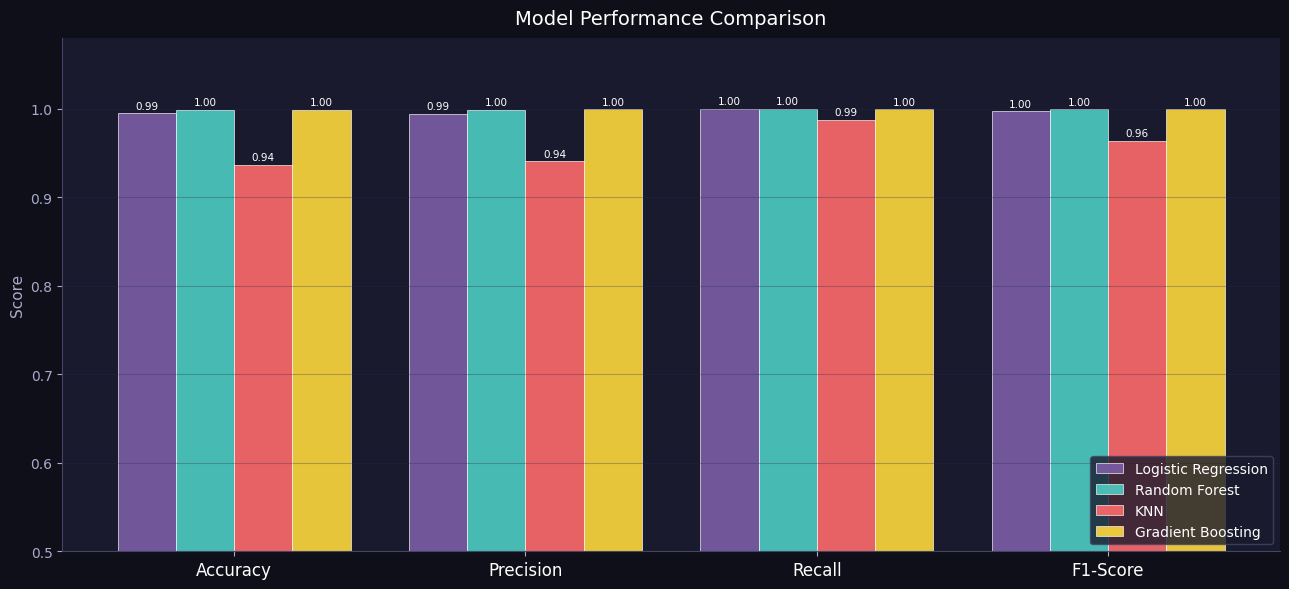

In [27]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.2
model_names = list(results.keys())
palette = ['#7b5ea7', '#4ecdc4', '#ff6b6b', '#ffd93d']

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

for i, (name, color) in enumerate(zip(model_names, palette)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width - 0.3, vals, width, label=name, color=color,
                  edgecolor='white', linewidth=0.5, alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7.5, color='white')

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12, color='white')
ax.set_ylim(0.5, 1.08)
ax.set_ylabel('Score', color='#aaaacc', fontsize=11)
ax.set_title('Model Performance Comparison', fontsize=14, color='white', pad=10)
ax.legend(fontsize=10, facecolor='#1a1a2e', edgecolor='#444466', labelcolor='white',
          loc='lower right')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/03_metrics_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

####  Best Model

In [28]:
best_model_name = results_df['F1-Score'].idxmax()
print(f" Best model: {best_model_name}")
print(f"   F1-Score : {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   Accuracy : {results_df.loc[best_model_name, 'Accuracy']:.4f}")
print()
print(results_df.to_string())

 Best model: Random Forest
   F1-Score : 0.9994
   Accuracy : 0.9990

                     Accuracy  Precision  Recall  F1-Score
Random Forest          0.9990     0.9988  1.0000    0.9994
Gradient Boosting      0.9984     0.9991  0.9991    0.9991
Logistic Regression    0.9949     0.9942  0.9998    0.9970
KNN                    0.9366     0.9406  0.9876    0.9636


---
##  Step 2 — Neural Network

### 2.1 Build & Train

In [29]:
from scipy.sparse import issparse

def to_dense(X):
    return X.toarray() if issparse(X) else X

X_tr = to_dense(X_train_tfidf).astype('float32')
X_te = to_dense(X_test_tfidf).astype('float32')
y_tr = y_train.values
y_te = y_test.values

tf.random.set_seed(42)

model_nn = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(5000,)),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
])

model_nn.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,473 (5.04 MB)

 Trainable params: 1,321,473 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model_nn.fit(
    X_tr, y_tr,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9289 - loss: 0.1563 - val_accuracy: 0.9960 - val_loss: 0.0096
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9980 - loss: 0.0061 - val_accuracy: 0.9970 - val_loss: 0.0048
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9998 - loss: 9.4636e-04 - val_accuracy: 0.9980 - val_loss: 0.0065
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9999 - loss: 6.6910e-04 - val_accuracy: 0.9975 - val_loss: 0.0065
Epoch 5/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9999 - loss: 1.9835e-04 - val_accuracy: 0.9970 - val_loss: 0.0080
Epoch 6/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 1.0000 - loss: 6.8188e-05 - val_accuracy: 0.9975 - val_loss: 0.0089
Epoch 7/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 1.0000 - loss: 3.2753e-05 - val_accuracy: 0.9970 - val_loss: 0.0086
Epoch 8/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9999 - los

####  Training Curves

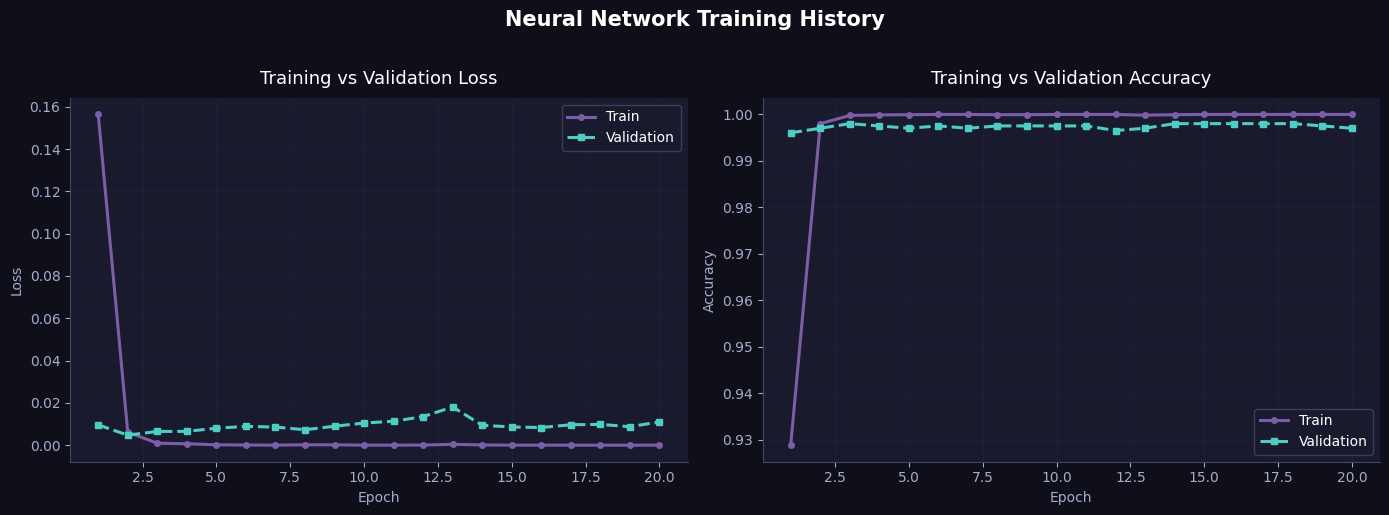

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, metric, title in zip(axes, ['loss','accuracy'], ['Loss','Accuracy']):
    ax.set_facecolor('#1a1a2e')
    epochs_range = range(1, len(history.history[metric])+1)
    ax.plot(epochs_range, history.history[metric],
            color='#7b5ea7', linewidth=2.2, marker='o', markersize=4, label='Train')
    ax.plot(epochs_range, history.history[f'val_{metric}'],
            color='#4ecdc4', linewidth=2.2, marker='s', markersize=4,
            linestyle='--', label='Validation')
    ax.set_title(f'Training vs Validation {title}', color='white', fontsize=13, pad=10)
    ax.set_xlabel('Epoch', color='#aaaacc'); ax.set_ylabel(title, color='#aaaacc')
    ax.legend(facecolor='#1a1a2e', edgecolor='#444466', labelcolor='white')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(alpha=0.3)

plt.suptitle('Neural Network Training History', fontsize=15,
             color='white', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/04_training_curves.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

### 2.2 Compare Neural Network with ML Models

In [32]:
nn_preds = (model_nn.predict(X_te) > 0.5).astype(int).flatten()

results['Neural Network'] = {
    'Accuracy' : round(accuracy_score(y_te, nn_preds),  4),
    'Precision': round(precision_score(y_te, nn_preds), 4),
    'Recall'   : round(recall_score(y_te, nn_preds),    4),
    'F1-Score' : round(f1_score(y_te, nn_preds),        4),
}
cms['Neural Network'] = confusion_matrix(y_te, nn_preds)

results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
print(results_df.to_string())

158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
                     Accuracy  Precision  Recall  F1-Score
Random Forest          0.9990     0.9988  1.0000    0.9994
Gradient Boosting      0.9984     0.9991  0.9991    0.9991
Neural Network         0.9982     0.9988  0.9991    0.9989
Logistic Regression    0.9949     0.9942  0.9998    0.9970
KNN                    0.9366     0.9406  0.9876    0.9636


####  Full Metrics Heatmap

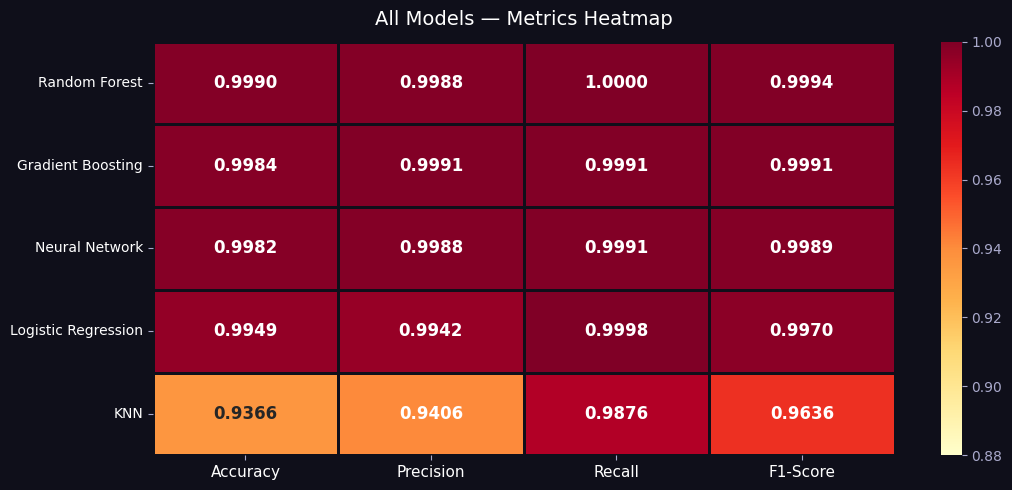

In [33]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0f0f1a')

pivot = results_df.astype(float)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.8, linecolor='#0f0f1a',
            ax=ax, vmin=0.88, vmax=1.0,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('All Models — Metrics Heatmap', color='white', fontsize=14, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), color='white', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), color='white', fontsize=10, rotation=0)

plt.tight_layout()
plt.savefig('plots/05_full_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

####  F1-Score Radar Chart

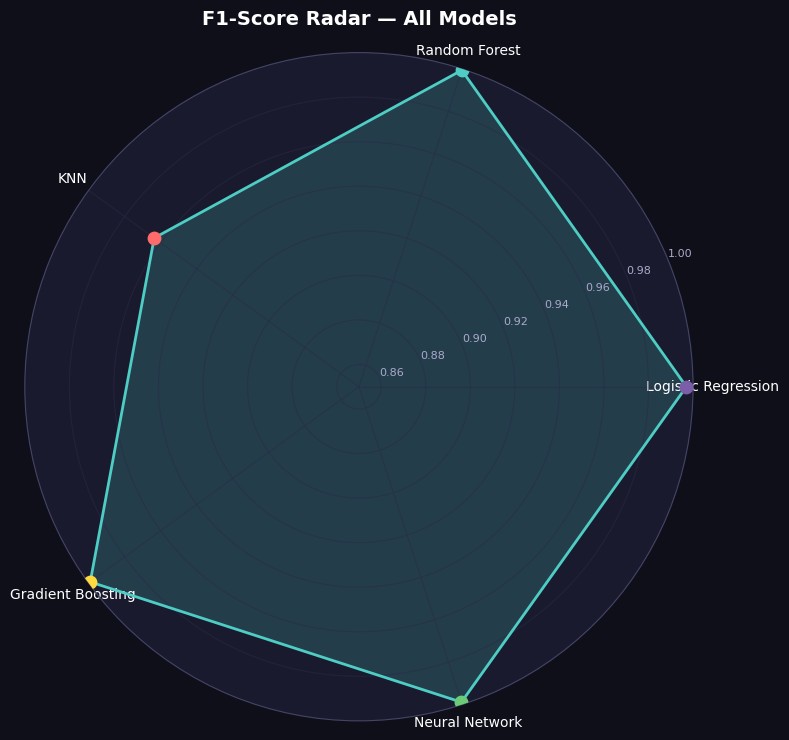

In [34]:
import matplotlib.patches as mpatches

model_names_all = list(results.keys())
f1_scores       = [results[m]['F1-Score'] for m in model_names_all]
colors_radar    = ['#7b5ea7','#4ecdc4','#ff6b6b','#ffd93d','#6bcb77']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

angles = [n / len(model_names_all) * 2 * np.pi for n in range(len(model_names_all))]
angles += angles[:1]
f1_plot = f1_scores + f1_scores[:1]

ax.plot(angles, f1_plot, color='#4ecdc4', linewidth=2, linestyle='solid')
ax.fill(angles, f1_plot, color='#4ecdc4', alpha=0.2)
for angle, val, name, color in zip(angles[:-1], f1_scores, model_names_all, colors_radar):
    ax.scatter(angle, val, color=color, s=80, zorder=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(model_names_all, color='white', fontsize=10)
ax.set_ylim(0.85, 1.0)
ax.yaxis.set_tick_params(labelcolor='#aaaacc', labelsize=8)
ax.grid(color='#2a2a4a', linewidth=0.8)
ax.set_title('F1-Score Radar — All Models', color='white', fontsize=14,
             pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/06_radar_f1.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()